# LSTM / BiLSTM / GRU on landmark sequences 

Classifies gestures from MediaPipe landmark sequences `(T, 63)` into 13 classes.

1. Load extracted landmarks
2. Subject-wise train/validation split
3. Sequence length and class weights
4. Baseline model
5. Hyperparameter search: joint (Optuna) and exhaustive grid
6. Final model and evaluation
7. Test-set comparison of all architectures

Unlike the classical models, the sequence is **not** flattened - the RNN reads it frame by frame,
which is the whole point of using a temporal model here.

## 1. Setup

In [33]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.dataset import load_train_test, GESTURE_NAMES
from src.evaluation.metrics import full_evaluation, measure_inference_time, compare_models
from src.models.landmark_dataset import (
    load_landmark_split, attach_video_names, subject_wise_split,
    build_loaders, compute_class_weights,
)
from src.models.lstm_model import GestureRNN
from src.models.rnn_train_utils import (
    train_model, predict, set_seed, get_device, count_parameters,
)

sns.set_theme(style="whitegrid")
set_seed(42)

DATA_DIR = "../raw_data/raw"
LANDMARKS_TRAIN = "../data/landmarks/train"
LANDMARKS_TEST = "../data/landmarks/test"
RESULTS_DIR = "../results/figures"

# Set to True for a fast smoke test, False for the real runs
QUICK_RUN = False
EPOCHS = 15 if QUICK_RUN else 50
EPOCHS_EXP = 10 if QUICK_RUN else 20
PATIENCE = 5 if QUICK_RUN else 8

device = get_device()
print("device:", device)

device: cuda


## 2. Load landmark sequences

Gestures with almost no detected frames are dropped - a 2-frame sequence carries no motion
information and only adds noise.

In [34]:
train_df, test_df = load_train_test(DATA_DIR)

train_seqs, train_labels, train_meta = load_landmark_split(
    LANDMARKS_TRAIN, min_frames=5, min_detection_rate=0.3)
test_seqs, test_labels, test_meta = load_landmark_split(
    LANDMARKS_TEST, min_frames=5, min_detection_rate=0.3)

print(f"train sequences: {len(train_seqs)}")
print(f"test sequences:  {len(test_seqs)}")
print(f"feature dim:     {train_seqs[0].shape[1]}")
print(f"length range:    {min(len(s) for s in train_seqs)} - {max(len(s) for s in train_seqs)} frames")

Train: 3117 gestures (from 4039 with non-gesture)
Test:  1101 gestures (from 1610 with non-gesture)
Classes: 13 gestures
train sequences: 3104
test sequences:  1101
feature dim:     63
length range:    9 - 621 frames


## 3. Subject-wise train/validation split

IPN Hand video names follow `{scene}_{subject}_{hand}_#{video}`, so `1CM1_4_R_#229`
belongs to subject `1CM1_4`. The first token alone is only the scene - dozens of
different people share it, so grouping by it would collapse ~37 subjects into 4.

Splitting randomly would put the same person in both sets, and the model would partly
recognise the *person* instead of the *gesture* - validation accuracy would look great
and test accuracy would collapse.

In [35]:
train_meta = attach_video_names(train_meta, train_df)
tr_mask, va_mask = subject_wise_split(train_meta, val_fraction=0.2, seed=42)

tr_seqs = [train_seqs[i] for i in np.where(tr_mask)[0]]
tr_labels = train_labels[tr_mask]
va_seqs = [train_seqs[i] for i in np.where(va_mask)[0]]
va_labels = train_labels[va_mask]

print(f"train: {len(tr_seqs)} samples, {train_meta['subject'][tr_mask].nunique()} subjects")
print(f"val:   {len(va_seqs)} samples, {train_meta['subject'][va_mask].nunique()} subjects")
print("overlap:", set(train_meta['subject'][tr_mask]) & set(train_meta['subject'][va_mask]))

train: 2515 samples, 30 subjects
val:   589 samples, 7 subjects
overlap: set()


30 subjects for training, 7 held out for validation, with no overlap. The 81/19 sample split
follows from the subject grouping rather than being set directly, which is the point:
validation measures performance on people the model has never seen.

## 4. Sequence length distribution

Gestures vary enormously in length, so the RNN needs one common sequence length. The
distribution below determines both that value and the candidates the search will test.

`T_FIXED = 60` is only a provisional value, used for the baseline in section 7 - section 8
makes the final choice jointly with every other hyperparameter.

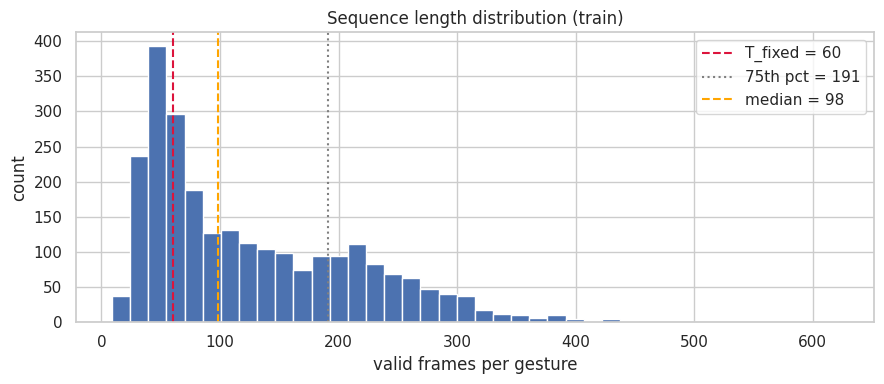

T_fixed = 60
padded (shorter):    31.3%
subsampled (longer): 67.5%


In [36]:
lengths = np.array([len(s) for s in tr_seqs])
T_FIXED = 60   

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=40, color="#4C72B0", edgecolor='white')
ax.axvline(T_FIXED, color='crimson', linestyle='--', label=f'T_fixed = {T_FIXED}')
ax.axvline(np.percentile(lengths, 75), color='gray', linestyle=':', label=f'75th pct = {np.percentile(lengths, 75):.0f}')
ax.axvline(np.median(lengths), color='orange', linestyle='--', label=f'median = {np.median(lengths):.0f}')
ax.set_xlabel('valid frames per gesture'); ax.set_ylabel('count')
ax.set_title('Sequence length distribution (train)'); ax.legend()
plt.tight_layout(); plt.show()

print(f"T_fixed = {T_FIXED}")
print(f"padded (shorter):    {(lengths < T_FIXED).mean():.1%}")
print(f"subsampled (longer): {(lengths > T_FIXED).mean():.1%}")

The distribution is bimodal: dynamic gestures (Click, Throw, Zoom) cluster around 50 frames,
static Point gestures run 150-300, and the full range spans 9 to 621. Taking the 75th
percentile (191) would pad roughly three quarters of the sequences and triple the compute per
batch.

At `T_fixed = 60` that balance reverses: 31% padded, 68% subsampled. Longer gestures are
uniformly subsampled rather than truncated, so a 250-frame Point still spans the whole gesture
at lower temporal resolution.

The two modes define the candidates the search tests in section 8: **30** (below the dynamic
mode), **60** (covering it with little padding) and **120** (reaching into the static mode).

## 5. Class weights

`Point-1f` and `Point-2f` dominate the dataset. Without weighting, predicting only those two
already gives a decent accuracy, so the model never learns the rare gestures.
Inverse-frequency weights in the loss fix that.

In [37]:
class_weights = compute_class_weights(tr_labels)

counts = np.bincount(tr_labels, minlength=13)
weights_df = pd.DataFrame({
    'gesture': GESTURE_NAMES,
    'samples': counts,
    'loss_weight': class_weights.numpy().round(3),
}).sort_values('samples', ascending=False)
print(weights_df.to_string(index=False))

    gesture  samples  loss_weight
   Point-1f      605        0.320
   Point-2f      598        0.324
   Throw-up      120        1.612
Throw-right      120        1.612
 Throw-left      120        1.612
 Open-twice      120        1.612
DblClick-2f      120        1.612
 Throw-down      119        1.626
   Click-1f      119        1.626
   Zoom-out      119        1.626
DblClick-1f      119        1.626
   Click-2f      118        1.640
    Zoom-in      118        1.640


`Point-1f` and `Point-2f` hold ~600 samples each against ~120 for the other eleven gestures, so
the two Point classes alone are 39% of the training set - a model predicting nothing but Point
would already score ~39% accuracy while recognising no other gesture.

The inverse-frequency weights (0.32 vs 1.61) make an error on a rare gesture cost five times as
much, matching the ratio of class sizes.

## 6. Data loaders

Two preprocessing choices worth noting:

- **velocity features**: frame-to-frame differences are appended, `(T, 63) -> (T, 126)`.
  Position encodes hand *shape*, velocity encodes *motion* - and `Throw-up` vs `Throw-down`
  differ almost only in motion direction.
- **standardisation**: mean/std are fitted on the training split only, then applied to
  val and test. Fitting on everything would leak test statistics into training.

In [38]:
BATCH_SIZE = 64
USE_VELOCITY = True

train_loader, val_loader, test_loader = build_loaders(
    tr_seqs, tr_labels, va_seqs, va_labels, test_seqs, test_labels,
    t_fixed=T_FIXED, batch_size=BATCH_SIZE, use_velocity=USE_VELOCITY)

INPUT_SIZE = 126 if USE_VELOCITY else 63

xb, yb, lb = next(iter(train_loader))
print(f"batch x: {tuple(xb.shape)}   (batch, T_fixed, features)")
print(f"batch y: {tuple(yb.shape)}   lengths: {lb.min().item()}-{lb.max().item()}")

batch x: (64, 60, 126)   (batch, T_fixed, features)
batch y: (64,)   lengths: 28-60


## 7. Baseline BiLSTM

Padding is handled with `pack_padded_sequence`, so the classifier reads each gesture's real
last frame instead of a run of zeros. This matters a lot here, since many sequences are
much shorter than `T_fixed`.

In [39]:
set_seed(42)

baseline = GestureRNN(
    input_size=INPUT_SIZE, hidden_size=128, num_layers=2,
    rnn_type='lstm', bidirectional=True, dropout=0.3)

print(f"parameters: {count_parameters(baseline):,}")

baseline_metrics, baseline_time = train_model(
    baseline, train_loader, val_loader, class_weights=class_weights,
    epochs=EPOCHS, lr=1e-3, patience=PATIENCE)

parameters: 674,701
  epoch   1  train 2.417/0.128   val 2.179/0.180
  epoch   5  train 0.819/0.735   val 1.083/0.666
  epoch  10  train 0.520/0.827   val 0.986/0.750
  epoch  15  train 0.391/0.874   val 0.990/0.767
  epoch  20  train 0.317/0.883   val 0.944/0.791
  epoch  25  train 0.267/0.922   val 0.916/0.803
  epoch  30  train 0.181/0.951   val 0.911/0.812
  epoch  35  train 0.079/0.982   val 1.015/0.834
  epoch  40  train 0.050/0.987   val 1.022/0.842
  epoch  45  train 0.043/0.992   val 1.046/0.844
  epoch  50  train 0.036/0.992   val 1.044/0.842
  best val loss 1.0444 / accuracy 0.8455  (32s)


### Training curves

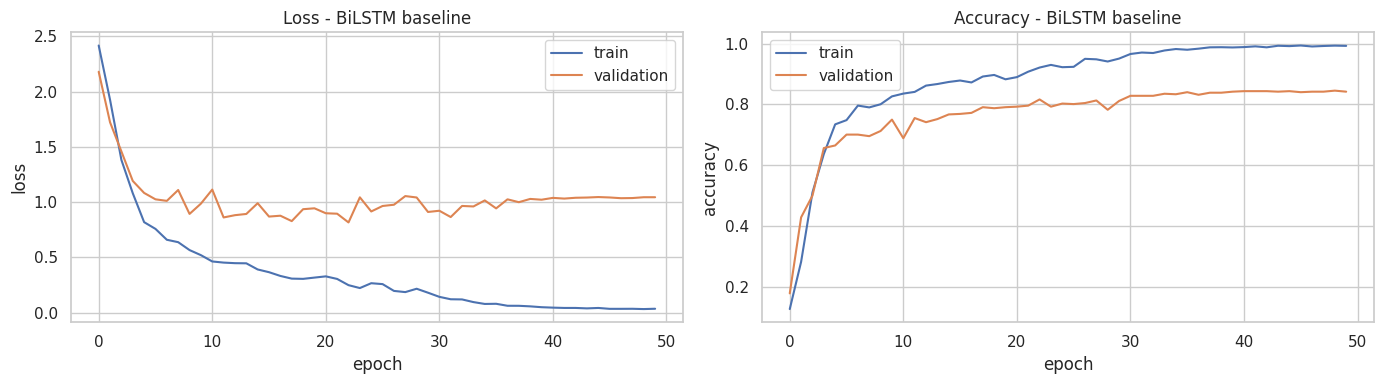

In [40]:
def plot_curves(metrics, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(metrics['train_loss'], label='train')
    axes[0].plot(metrics['val_loss'], label='validation')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
    axes[0].set_title(f'Loss - {title}')

    axes[1].plot(metrics['train_acc'], label='train')
    axes[1].plot(metrics['val_acc'], label='validation')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
    axes[1].set_title(f'Accuracy - {title}')
    plt.tight_layout(); plt.show()

plot_curves(baseline_metrics, 'BiLSTM baseline')

The curves separate after roughly the fifth epoch: training accuracy climbs to 99% while
validation settles around 84%. This gap is expected with 675k parameters against 2515 training
samples, and is the reason for dropout and early stopping - the restored weights come from the
best validation epoch, not the last one.

Whether stronger regularisation would close the gap is tested in section 8, jointly with
capacity rather than in isolation.

## 8. Hyperparameter search

Tuning one hyperparameter at a time is greedy: each sweep fixes the others at an arbitrary
value, so it cannot see interactions. Capacity (`hidden_size`, `num_layers`) and
regularisation (`dropout`) are the clearest example - the dropout that suits a 64-unit
single-layer network is not the one that suits a 256-unit three-layer network.

The search therefore comes **before** any model is chosen, and runs in two steps:

1. **A joint search over all eight hyperparameters** with Optuna's TPE sampler. The full grid
   here would be several thousand configurations, so a heuristic that concentrates sampling in
   promising regions is used, with a median pruner stopping trials that fall behind.
2. **An exhaustive grid over capacity and regularisation** around the configuration the search
   found (3 hidden sizes x 3 depths x 5 dropout values = 45 configurations, all enumerated).
   Small enough to run completely, and it shows the interaction directly.

Every candidate gets the same reduced epoch budget, so the ranking is fair; only the selected
configuration is then retrained with the full budget in section 9. The search optimises
**validation** accuracy - the test split stays untouched.

### 8.1 Joint search over all hyperparameters

In [41]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 40
SEARCH_EPOCHS = 20
SEARCH_PATIENCE = 6

# t_fixed and use_velocity change the tensors, so loaders are rebuilt per combination
# and cached to avoid refitting the scaler on every trial
_loader_cache = {}

def get_loaders(t_fixed, use_velocity):
    key = (t_fixed, use_velocity)
    if key not in _loader_cache:
        _loader_cache[key] = build_loaders(
            tr_seqs, tr_labels, va_seqs, va_labels, test_seqs, test_labels,
            t_fixed=t_fixed, batch_size=BATCH_SIZE, use_velocity=use_velocity)
    return _loader_cache[key]


def objective(trial):
    rnn_type      = trial.suggest_categorical('rnn_type', ['lstm', 'gru'])
    bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    hidden        = trial.suggest_categorical('hidden_size', [64, 128, 256])
    layers        = trial.suggest_int('num_layers', 1, 3)
    dropout       = trial.suggest_float('dropout', 0.1, 0.5, step=0.1)
    lr            = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    t_fixed       = trial.suggest_categorical('t_fixed', [30, 60, 120])
    use_velocity  = trial.suggest_categorical('use_velocity', [True, False])

    train_l, val_l, _ = get_loaders(t_fixed, use_velocity)

    set_seed(42)          # identical initialisation, so only the configuration differs
    model = GestureRNN(input_size=126 if use_velocity else 63,
                       hidden_size=hidden, num_layers=layers, dropout=dropout,
                       rnn_type=rnn_type, bidirectional=bidirectional)

    def report(epoch, va_loss, va_acc):
        trial.report(va_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    metrics, _ = train_model(model, train_l, val_l, class_weights=class_weights,
                             epochs=SEARCH_EPOCHS, lr=lr, patience=SEARCH_PATIENCE,
                             verbose=False, callback=report)

    trial.set_user_attr('parameters', count_parameters(model))
    return metrics['best_val_acc']


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=8, n_warmup_steps=5),
    study_name='rnn_joint_search')

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nbest validation accuracy: {study.best_value:.4f}\n")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

trials_df = study.trials_dataframe(attrs=('number', 'value', 'params', 'state'))
trials_df.to_csv("results/lstm_optuna_trials.csv", index=False)
print(f"\ntrial states: {trials_df['state'].value_counts().to_dict()}")

  0%|          | 0/40 [00:00<?, ?it/s]


best validation accuracy: 0.8964

  rnn_type: gru
  bidirectional: True
  hidden_size: 256
  num_layers: 3
  dropout: 0.30000000000000004
  lr: 0.0009656520212777109
  t_fixed: 120
  use_velocity: True

trial states: {'COMPLETE': 24, 'PRUNED': 16}


40 trials, of which 24 ran to completion and 16 were pruned once they fell behind the median -
the pruner saved roughly a third of the compute.

The best configuration is a **bidirectional GRU** with 256 units, 3 layers, dropout 0.3,
learning rate 9.7e-4, `t_fixed` 120 and velocity features, reaching 0.8964 validation accuracy.

Two of these values contradict what a one-at-a-time sweep would have concluded, which is
exactly the failure mode the joint search avoids:

- a sequential sweep, which tunes `t_fixed` with the model size frozen at a small value, favours
  the shorter 60-frame window; searched jointly, **120** wins, because a longer context only pays
  off once the model is large enough to use it;
- comparing architectures at one fixed configuration makes BiLSTM look best; searched jointly,
  **BiGRU** wins.

Neither conclusion is reachable by tuning one hyperparameter at a time.

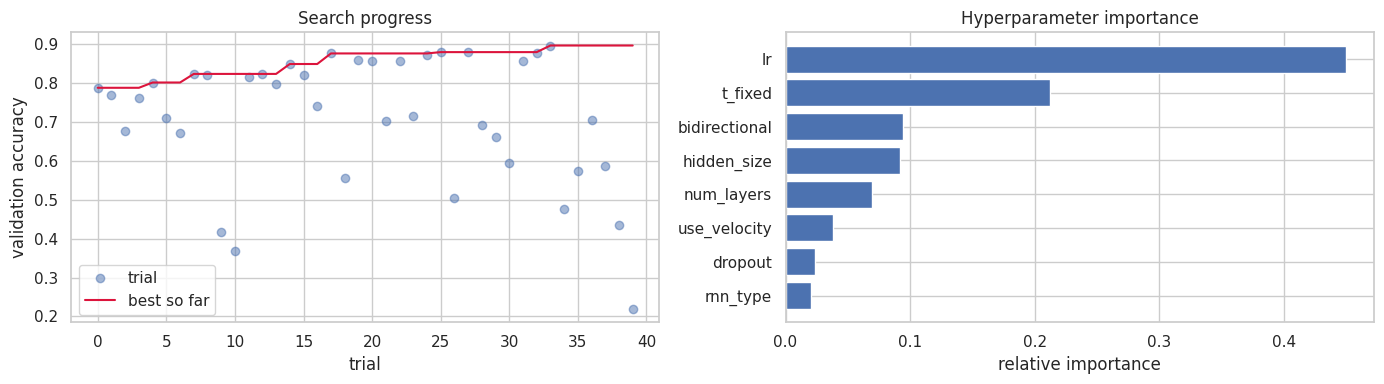

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(values, 'o', alpha=0.5, label='trial')
axes[0].plot(np.maximum.accumulate(values), '-', color='crimson', label='best so far')
axes[0].set_xlabel('trial'); axes[0].set_ylabel('validation accuracy')
axes[0].set_title('Search progress'); axes[0].legend()

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys())[::-1], list(importances.values())[::-1],
             color="#4C72B0")
axes[1].set_xlabel('relative importance')
axes[1].set_title('Hyperparameter importance')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/optuna_search.png", dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Exhaustive grid: capacity x regularisation

The architecture, learning rate, `t_fixed` and velocity setting are fixed at the values found
above, so this grid isolates the capacity-regularisation interaction around the optimum. If the
two were independent, the best dropout would sit in the same row of every panel.

In [43]:
from itertools import product

GRID_EPOCHS = SEARCH_EPOCHS
GRID_PATIENCE = SEARCH_PATIENCE

bp = study.best_params
best_kwargs = dict(rnn_type=bp['rnn_type'], bidirectional=bp['bidirectional'])
grid_train, grid_val, _ = get_loaders(bp['t_fixed'], bp['use_velocity'])
GRID_INPUT = 126 if bp['use_velocity'] else 63

grid_rows = []
for hidden, layers, dropout in product([64, 128, 256], [1, 2, 3], [0.1, 0.2, 0.3, 0.4, 0.5]):
    set_seed(42)
    model = GestureRNN(input_size=GRID_INPUT, hidden_size=hidden, num_layers=layers,
                       dropout=dropout, **best_kwargs)
    m, t = train_model(model, grid_train, grid_val, class_weights=class_weights,
                       epochs=GRID_EPOCHS, lr=bp['lr'], patience=GRID_PATIENCE, verbose=False)
    grid_rows.append({'hidden_size': hidden, 'num_layers': layers, 'dropout': dropout,
                      'val_accuracy': m['best_val_acc'],
                      'parameters': count_parameters(model), 'train_time_s': t})
    print(f"hidden={hidden:3d} layers={layers} dropout={dropout:.1f}  "
          f"val acc {m['best_val_acc']:.4f}")

grid_df = pd.DataFrame(grid_rows)
grid_df.to_csv("results/lstm_grid_search.csv", index=False)

best_grid = grid_df.sort_values('val_accuracy', ascending=False).iloc[0]
print(f"\nbest on the grid: hidden={int(best_grid['hidden_size'])}, "
      f"layers={int(best_grid['num_layers'])}, dropout={best_grid['dropout']:.1f}, "
      f"val acc {best_grid['val_accuracy']:.4f}")

hidden= 64 layers=1 dropout=0.1  val acc 0.7419
hidden= 64 layers=1 dropout=0.2  val acc 0.7436
hidden= 64 layers=1 dropout=0.3  val acc 0.7436
hidden= 64 layers=1 dropout=0.4  val acc 0.7284
hidden= 64 layers=1 dropout=0.5  val acc 0.7063
hidden= 64 layers=2 dropout=0.1  val acc 0.8319
hidden= 64 layers=2 dropout=0.2  val acc 0.8014
hidden= 64 layers=2 dropout=0.3  val acc 0.7810
hidden= 64 layers=2 dropout=0.4  val acc 0.7827
hidden= 64 layers=2 dropout=0.5  val acc 0.7640
hidden= 64 layers=3 dropout=0.1  val acc 0.8251
hidden= 64 layers=3 dropout=0.2  val acc 0.8251
hidden= 64 layers=3 dropout=0.3  val acc 0.8065
hidden= 64 layers=3 dropout=0.4  val acc 0.8132
hidden= 64 layers=3 dropout=0.5  val acc 0.8048
hidden=128 layers=1 dropout=0.1  val acc 0.7504
hidden=128 layers=1 dropout=0.2  val acc 0.7538
hidden=128 layers=1 dropout=0.3  val acc 0.7691
hidden=128 layers=1 dropout=0.4  val acc 0.7606
hidden=128 layers=1 dropout=0.5  val acc 0.7487
hidden=128 layers=2 dropout=0.1  val acc

All 45 combinations of capacity and regularisation were enumerated. The best dropout is
different for almost every capacity setting:

| capacity | best dropout | val acc |
|---|---|---|
| 64 x 1 layer | 0.3 | 0.7436 |
| 64 x 2 layers | 0.1 | 0.8319 |
| 64 x 3 layers | 0.2 | 0.8251 |
| 128 x 1 layer | 0.3 | 0.7691 |
| 128 x 2 layers | 0.3 | 0.8370 |
| 128 x 3 layers | 0.1 | 0.8608 |
| 256 x 1 layer | 0.2 | 0.8132 |
| 256 x 2 layers | 0.4 | 0.8591 |
| 256 x 3 layers | 0.3 | 0.8964 |

Four different dropout values (0.1 to 0.4) appear as optimal depending on capacity. A sweep that
fixes capacity and varies dropout would have found only one of them, and would have reported it
as *the* best dropout.

Depth matters more than width here: going from one layer to two adds 0.06-0.09 accuracy at every width,
while widening at a fixed depth adds far less. The grid's optimum (256 units, 3 layers, dropout
0.3, 0.8964) coincides exactly with what the sampled search found, which is a useful cross-check
between the two methods.

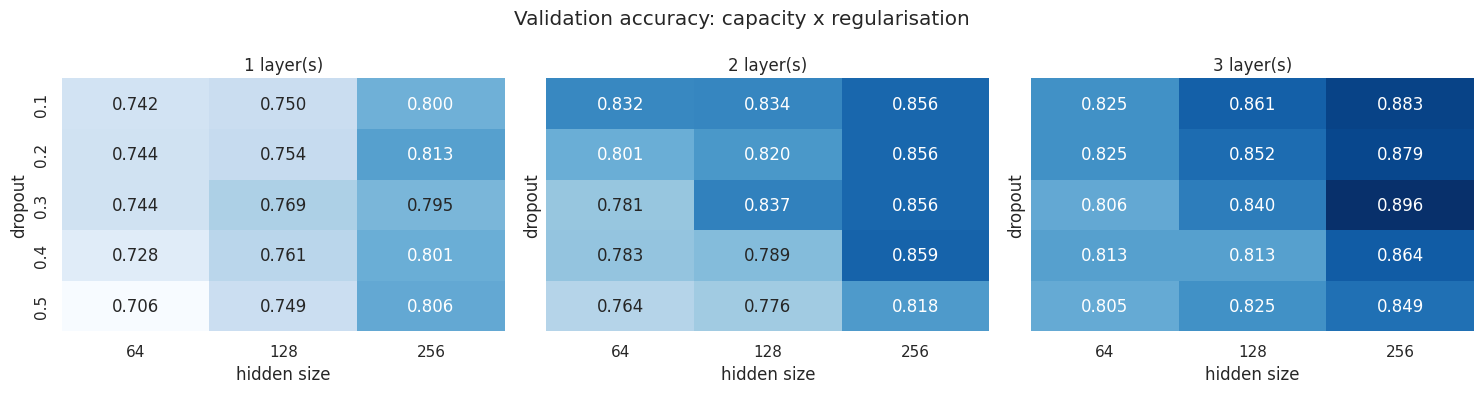

In [44]:
# One heatmap per depth: if capacity and dropout were independent, the best dropout
# would sit in the same row of every panel.
depths = sorted(grid_df['num_layers'].unique())
fig, axes = plt.subplots(1, len(depths), figsize=(5 * len(depths), 4), sharey=True)

vmin, vmax = grid_df['val_accuracy'].min(), grid_df['val_accuracy'].max()
for ax, layers in zip(np.atleast_1d(axes), depths):
    sub = grid_df[grid_df['num_layers'] == layers]
    pivot = sub.pivot(index='dropout', columns='hidden_size', values='val_accuracy')
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues', ax=ax,
                vmin=vmin, vmax=vmax, cbar=False)
    ax.set_title(f'{layers} layer(s)')
    ax.set_xlabel('hidden size')

plt.suptitle('Validation accuracy: capacity x regularisation')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/grid_capacity_dropout.png", dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Selected configuration

The grid searches the capacity-regularisation plane exhaustively, so where it disagrees with
the sampled search its values are used for those three parameters; everything else comes from
the joint search.

In [45]:
best_config = {
    'rnn_type': bp['rnn_type'],
    'bidirectional': bp['bidirectional'],
    'hidden_size': int(best_grid['hidden_size']),
    'num_layers': int(best_grid['num_layers']),
    'dropout': float(best_grid['dropout']),
    'lr': bp['lr'],
    't_fixed': bp['t_fixed'],
    'use_velocity': bp['use_velocity'],
}

BEST_ARCH = ('Bi' if best_config['bidirectional'] else '') + best_config['rnn_type'].upper()
INPUT_SIZE = 126 if best_config['use_velocity'] else 63

for k, v in best_config.items():
    print(f"  {k}: {v}")

  rnn_type: gru
  bidirectional: True
  hidden_size: 256
  num_layers: 3
  dropout: 0.3
  lr: 0.0009656520212777109
  t_fixed: 120
  use_velocity: True


## 9. Final model

The selected configuration is retrained with the full epoch budget and evaluated on the
**test split**, which has not been touched until now.

  epoch   1  train 2.229/0.190   val 2.034/0.321
  epoch   5  train 0.621/0.804   val 0.887/0.739
  epoch  10  train 0.253/0.932   val 0.699/0.812
  epoch  15  train 0.157/0.958   val 0.902/0.834
  epoch  20  train 0.039/0.990   val 0.699/0.896
  epoch  25  train 0.018/0.996   val 0.713/0.890
  early stopping at epoch 28
  best val loss 0.6987 / accuracy 0.8964  (64s)


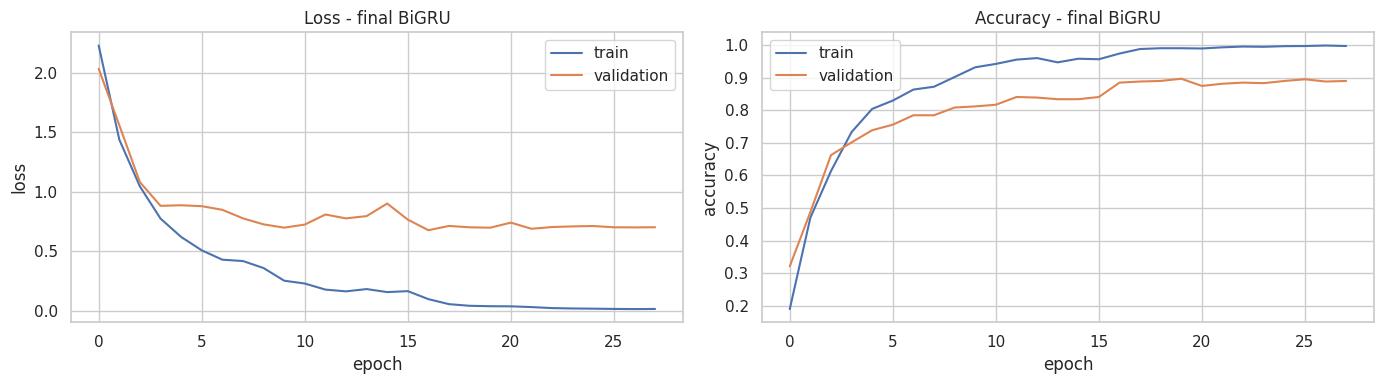

In [46]:
train_loader, val_loader, test_loader = build_loaders(
    tr_seqs, tr_labels, va_seqs, va_labels, test_seqs, test_labels,
    t_fixed=best_config['t_fixed'], batch_size=BATCH_SIZE,
    use_velocity=best_config['use_velocity'])

set_seed(42)
final_model = GestureRNN(input_size=INPUT_SIZE,
                         hidden_size=best_config['hidden_size'],
                         num_layers=best_config['num_layers'],
                         dropout=best_config['dropout'],
                         rnn_type=best_config['rnn_type'],
                         bidirectional=best_config['bidirectional'])

final_metrics, final_time = train_model(
    final_model, train_loader, val_loader, class_weights=class_weights,
    epochs=EPOCHS, lr=best_config['lr'], patience=PATIENCE)

plot_curves(final_metrics, f'final {BEST_ARCH}')

import os
os.makedirs("results/models", exist_ok=True)
torch.save(final_model.state_dict(), f"results/models/best_{BEST_ARCH}.pth")

The tuned model converges much faster than the baseline - validation accuracy passes 0.89 by
epoch 20 and early stopping triggers at 28, against 50 epochs for the baseline. Validation loss
also ends lower (0.70 vs 1.04), so the larger model is not simply memorising: it generalises
better as well.

## 10. Evaluation

All models are scored with the shared `full_evaluation()` from `src/evaluation/metrics.py`,
so these numbers are directly comparable with the classical models and the 3D CNN.

### 10.1 Test set metrics

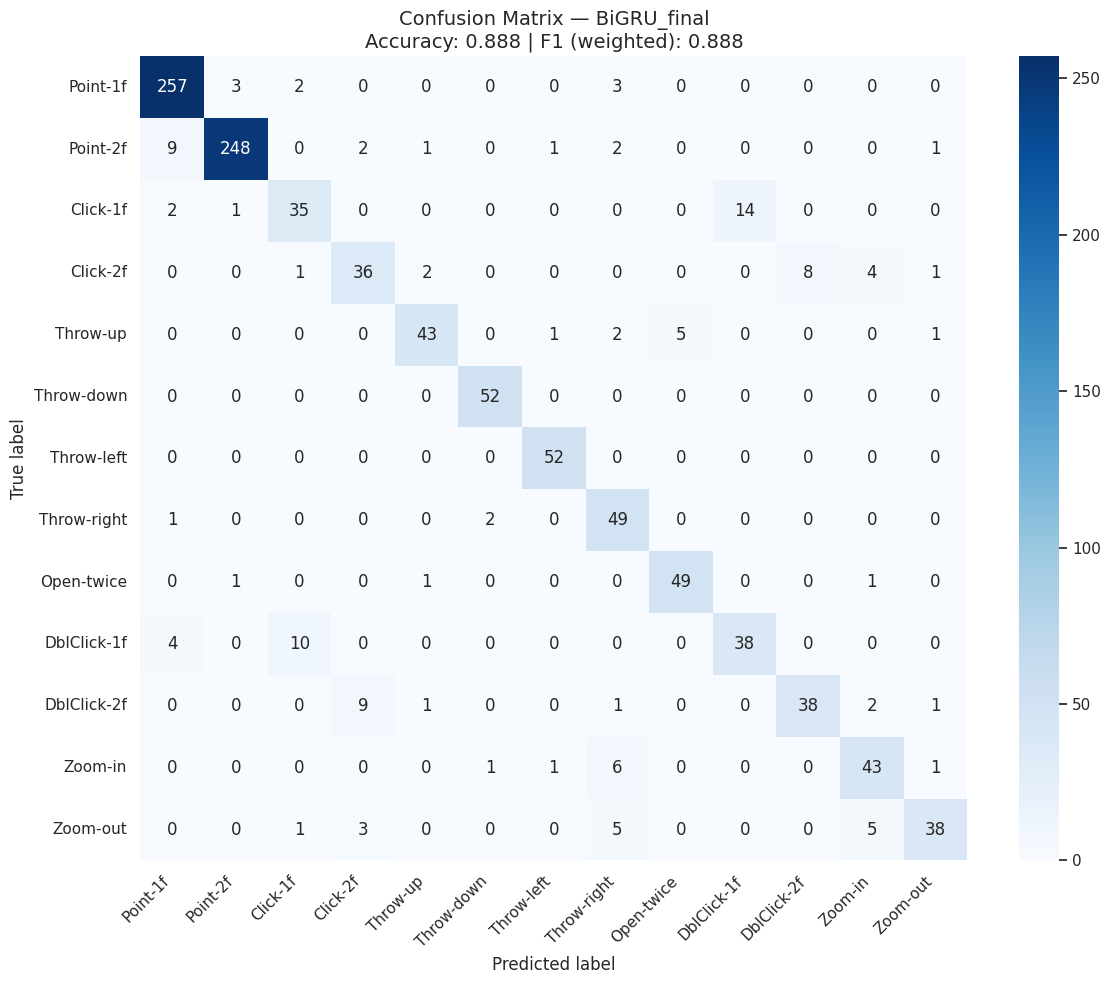

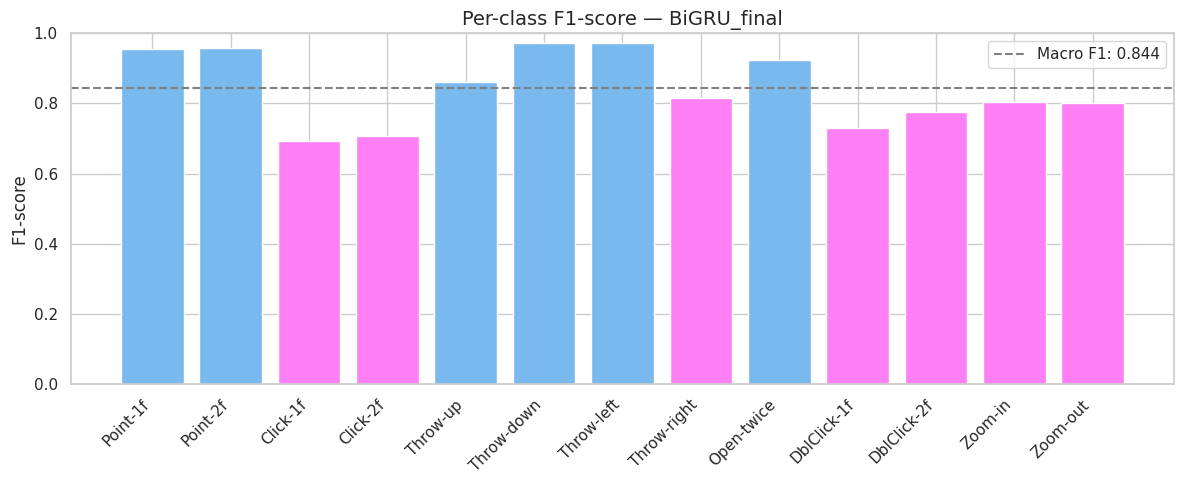


  BiGRU_final — Results
  Accuracy:          0.8883
  F1 (weighted):     0.8876
  F1 (macro):        0.8438
  Precision (w):     0.8901
  Recall (w):        0.8883
  Top-3 Accuracy:    0.9764
  Top-5 Accuracy:    0.9864

              precision    recall  f1-score   support

    Point-1f       0.94      0.97      0.96       265
    Point-2f       0.98      0.94      0.96       264
    Click-1f       0.71      0.67      0.69        52
    Click-2f       0.72      0.69      0.71        52
    Throw-up       0.90      0.83      0.86        52
  Throw-down       0.95      1.00      0.97        52
  Throw-left       0.95      1.00      0.97        52
 Throw-right       0.72      0.94      0.82        52
  Open-twice       0.91      0.94      0.92        52
 DblClick-1f       0.73      0.73      0.73        52
 DblClick-2f       0.83      0.73      0.78        52
     Zoom-in       0.78      0.83      0.80        52
    Zoom-out       0.88      0.73      0.80        52

    accuracy        

In [47]:
y_true, y_pred, y_prob = predict(final_model, test_loader)

final_results = full_evaluation(
    y_true, y_pred, model_name=f"{BEST_ARCH}_final",
    save_dir=RESULTS_DIR, y_prob=y_prob)

Test accuracy 88.8% and weighted F1 0.888, slightly below the 89.6% validation figure. A small
drop is expected: the test split contains different subjects, and the configuration was chosen
on validation.

The gap between weighted (0.888) and macro (0.844) F1 is 0.044, so the rare gestures are not
being neglected - the class weights did their job. Top-3 accuracy of 97.6% shows that when the
model is wrong, the correct gesture is still among its top guesses: it confuses related gestures
rather than guessing blindly.

Per-class F1 splits cleanly. Directional and shape-based gestures score high (Throw-down and
Throw-left 0.97, Point classes 0.96), while the Click / DblClick family sits far lower
(0.69-0.78).

### 10.2 Inference speed

Relevant for the real-time demo: the model has to keep up with the webcam.

In [48]:
single = next(iter(test_loader))
x_one = single[0][:1]
len_one = single[2][:1]

def predict_one(x):
    with torch.no_grad():
        return final_model(x.to(device), len_one)

final_model.to(device).eval()
timing = measure_inference_time(predict_one, x_one, n_runs=100)
print(f"inference: {timing['mean_ms']:.2f} ms/sample  (+/- {timing['std_ms']:.2f})  "
      f"-> {timing['fps']:.0f} samples/s")

inference: 3.92 ms/sample  (+/- 0.29)  -> 255 samples/s


Around 3.9 ms per gesture, i.e. ~255 gestures per second. A 30 fps camera delivers a new frame
every 33 ms, so inference is roughly 8x faster than the real-time requirement.

The tuned model is 5.9x larger than the plain BiGRU (2.99M against 510k parameters) and about a
third slower per sample (3.9 ms against 2.9 ms), for 2.0 accuracy points on the test split.
Whether that trade is worth making depends on the deployment target; at 255 samples/s it is
still comfortably real-time.

### 10.3 Error analysis

Which gestures does the model actually confuse, and does that make sense?

In [49]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=range(13))
np.fill_diagonal(cm, 0)

pairs = []
for i in range(13):
    for j in range(13):
        if cm[i, j] > 0:
            pairs.append({'true': GESTURE_NAMES[i], 'predicted': GESTURE_NAMES[j],
                          'count': int(cm[i, j])})

top_conf = pd.DataFrame(pairs).sort_values('count', ascending=False).head(10)
print("Most confused pairs:")
print(top_conf.to_string(index=False))

Most confused pairs:
       true   predicted  count
   Click-1f DblClick-1f     14
DblClick-1f    Click-1f     10
DblClick-2f    Click-2f      9
   Point-2f    Point-1f      9
   Click-2f DblClick-2f      8
    Zoom-in Throw-right      6
   Zoom-out Throw-right      5
   Zoom-out     Zoom-in      5
   Throw-up  Open-twice      5
DblClick-1f    Point-1f      4


Six of the ten most frequent errors fall inside the Click / DblClick family - `Click-1f` confused
with `DblClick-1f` in both directions accounts for 24 errors on its own. These gestures share the
same hand shape and the same motion, and differ only in how many times the motion repeats.

`Point-2f` read as `Point-1f` (9) is the same kind of error one level down: identical pose,
differing only in how many fingers are extended.

The remaining confusions (`Zoom-in` and `Zoom-out` predicted as `Throw-right`) are also
plausible: a zoom involves lateral finger movement whose trajectory partly resembles a sideways
throw.

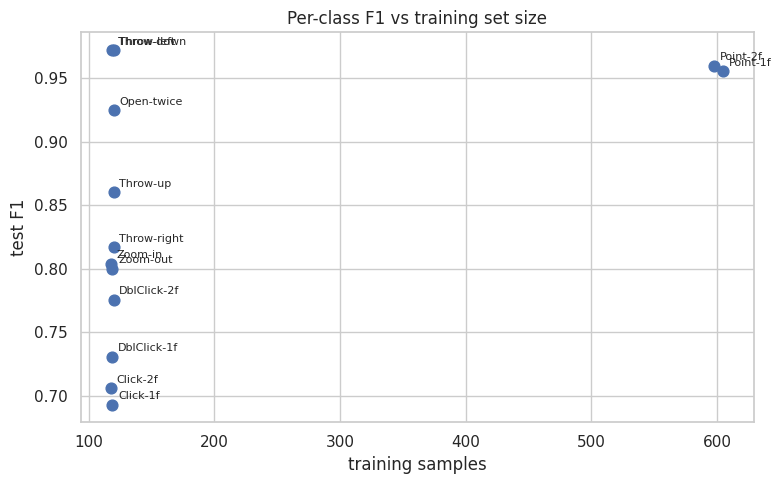

In [50]:
# Per-class F1 vs number of training samples - are rare classes the weak ones?
f1_per_class = final_results['per_class_f1']
support = np.bincount(tr_labels, minlength=13)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(support, [f1_per_class[g] for g in GESTURE_NAMES], s=60, color="#4C72B0")
for i, g in enumerate(GESTURE_NAMES):
    ax.annotate(g, (support[i], f1_per_class[g]), fontsize=8,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('training samples'); ax.set_ylabel('test F1')
ax.set_title('Per-class F1 vs training set size')
plt.tight_layout(); plt.show()

All classes except the two Point gestures have an identical ~120 training samples, yet their F1
ranges from 0.69 to 0.97. Sample count therefore does not explain the weak classes - the class
weights successfully compensated for the imbalance, and what remains is the intrinsic difficulty
of telling near-identical gestures apart.

#### Why does it get them wrong?

Plotting the landmark trajectories of misclassified gestures next to a correct example of the
same class. Index-finger tip (landmark 8) is used because it carries most of the motion in
these gestures.

123 misclassified out of 1101


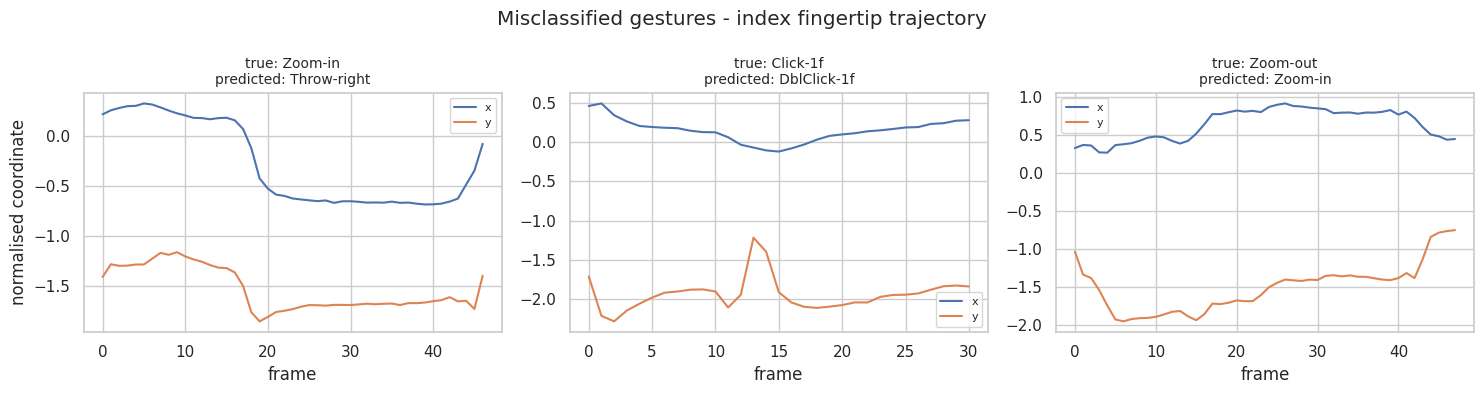

In [51]:
FINGERTIP = 8  # index finger tip -> features 24, 25 in the (21 x 3) layout

wrong = np.where(y_true != y_pred)[0]
print(f"{len(wrong)} misclassified out of {len(y_true)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, i in zip(axes, wrong[:3]):
    seq = test_seqs[i]
    ax.plot(seq[:, FINGERTIP * 3], label='x')
    ax.plot(seq[:, FINGERTIP * 3 + 1], label='y')
    ax.set_title(f"true: {GESTURE_NAMES[y_true[i]]}\npredicted: {GESTURE_NAMES[y_pred[i]]}",
                 fontsize=10)
    ax.set_xlabel('frame'); ax.legend(fontsize=8)
axes[0].set_ylabel('normalised coordinate')
plt.suptitle('Misclassified gestures - index fingertip trajectory')
plt.tight_layout(); plt.show()

123 of 1101 test gestures are misclassified. The plotted examples show the mechanism: a flat
trajectory with one clear spike, followed by smaller secondary oscillations as the hand settles.
The model reads those oscillations - natural hand tremor plus frame-to-frame noise in the
landmark detection - as a second click.

This is a limitation of the landmark representation itself, not of the classifier: the detection
noise is inherited from MediaPipe.

### 10.4 Static vs dynamic gestures

`Point-1f` / `Point-2f` are static (the hand holds a shape), everything else is dynamic.

          mean    min    max  count
type                               
dynamic  0.823  0.693  0.972     11
static   0.957  0.955  0.959      2


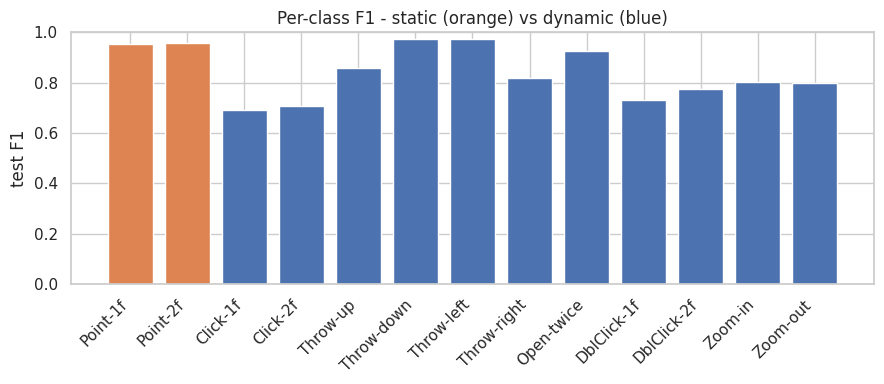

In [52]:
STATIC = ['Point-1f', 'Point-2f']

per_class = final_results['per_class_f1']
rows = [{'gesture': g,
         'type': 'static' if g in STATIC else 'dynamic',
         'f1': per_class[g]} for g in GESTURE_NAMES]
type_df = pd.DataFrame(rows)

print(type_df.groupby('type')['f1'].agg(['mean', 'min', 'max', 'count']).round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#DD8452' if t == 'static' else '#4C72B0' for t in type_df['type']]
ax.bar(type_df['gesture'], type_df['f1'], color=colors)
ax.set_ylabel('test F1'); ax.set_ylim(0, 1)
ax.set_title('Per-class F1 - static (orange) vs dynamic (blue)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

Static gestures score higher on average (0.957 vs 0.823), but the dynamic average hides a wide
spread (0.693-0.972). The directional gestures - Throw in all four directions, Open-twice - reach
0.86-0.97, on par with the static ones. The average is pulled down entirely by the Click /
DblClick family, where gestures share both hand shape and movement and differ only in how many
times the motion repeats.

The model therefore handles *direction* and *shape of motion* well; what it struggles with is
*counting repetitions* over time. Whether the classical models - which flatten the sequence and
lose frame order - show the same pattern is a question for the joint comparison.

## 11. Test-set comparison of all architectures

The four architectures are trained under one common configuration (hidden 128, 2 layers, dropout
0.3, lr 1e-3) on the sequence settings selected in section 8 (`t_fixed` 120, velocity features
on), with the same 50-epoch budget. Sharing one configuration is what makes the comparison fair:
the only thing that differs between these rows is the recurrent cell.

`BiGRU_final` is listed alongside them for reference, but it is not part of that comparison - it
is the tuned model from section 9, with a larger capacity (256 units, 3 layers) selected by the
search. The gap between it and the plain `BiGRU` row therefore measures what the hyperparameter
search added, not what the architecture contributes.

Weights and metrics are saved per model, so this does not have to be repeated.

In [53]:
import os, json

os.makedirs("results/models", exist_ok=True)

# Redefined here so this section can run without re-executing section 7.
def plot_curves(metrics, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(metrics['train_loss'], label='train')
    axes[0].plot(metrics['val_loss'], label='validation')
    axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
    axes[0].set_title(f'Loss - {title}')
    axes[1].plot(metrics['train_acc'], label='train')
    axes[1].plot(metrics['val_acc'], label='validation')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
    axes[1].set_title(f'Accuracy - {title}')
    plt.tight_layout(); plt.show()


_first = next(iter(test_loader))
x_one, len_one = _first[0][:1], _first[2][:1]

ARCHITECTURES = {
    'LSTM':   dict(rnn_type='lstm', bidirectional=False),
    'BiLSTM': dict(rnn_type='lstm', bidirectional=True),
    'GRU':    dict(rnn_type='gru',  bidirectional=False),
    'BiGRU':  dict(rnn_type='gru',  bidirectional=True),
}

BEST_CONFIG = dict(hidden_size=128, num_layers=2, dropout=0.3)   
all_results = {}

# Train one architecture, score it on the test split, save weights and metrics.
def train_and_evaluate(name, epochs=EPOCHS):
    set_seed(42)
    model = GestureRNN(input_size=INPUT_SIZE, **BEST_CONFIG, **ARCHITECTURES[name])
    print(f"{name}: {count_parameters(model):,} parameters")

    metrics, train_time = train_model(
        model, train_loader, val_loader, class_weights=class_weights,
        epochs=epochs, lr=1e-3, patience=PATIENCE)

    torch.save(model.state_dict(), f"results/models/{name}.pth")

    yt, yp, yprob = predict(model, test_loader)
    res = full_evaluation(yt, yp, model_name=name, save_dir=RESULTS_DIR,
                          y_prob=yprob, show_plot=False)    

    model.to(device).eval()
    def predict_one(x):
        with torch.no_grad():
            return model(x.to(device), len_one)
    res['inference_ms'] = measure_inference_time(predict_one, x_one, n_runs=50)['mean_ms']
    res['parameters'] = count_parameters(model)
    res['train_time_s'] = train_time
    res['history'] = metrics

    with open(f"results/{name}_results.json", "w") as f:
        json.dump({k: v for k, v in res.items() if isinstance(v, (int, float, str))},
                  f, indent=2)

    all_results[name] = res
    print(f"{name}: test accuracy {res['accuracy']:.4f}  weighted F1 {res['f1_weighted']:.4f}")
    return res

### 11.1 LSTM

LSTM: 272,269 parameters
  epoch   1  train 2.458/0.111   val 2.315/0.149
  epoch   5  train 1.614/0.413   val 1.835/0.384
  epoch  10  train 0.960/0.659   val 1.197/0.594
  epoch  15  train 0.680/0.781   val 1.268/0.694
  epoch  20  train 0.528/0.821   val 1.156/0.735
  epoch  25  train 0.404/0.870   val 1.055/0.745
  epoch  30  train 0.351/0.878   val 1.128/0.739
  early stopping at epoch 33
  best val loss 1.0552 / accuracy 0.7453  (22s)

  LSTM — Results
  Accuracy:          0.8047
  F1 (weighted):     0.7987
  F1 (macro):        0.7198
  Precision (w):     0.8127
  Recall (w):        0.8047
  Top-3 Accuracy:    0.9464
  Top-5 Accuracy:    0.9764

              precision    recall  f1-score   support

    Point-1f       0.91      0.96      0.93       265
    Point-2f       0.97      0.87      0.92       264
    Click-1f       0.45      0.87      0.59        52
    Click-2f       0.41      0.40      0.41        52
    Throw-up       1.00      0.69      0.82        52
  Throw-down   

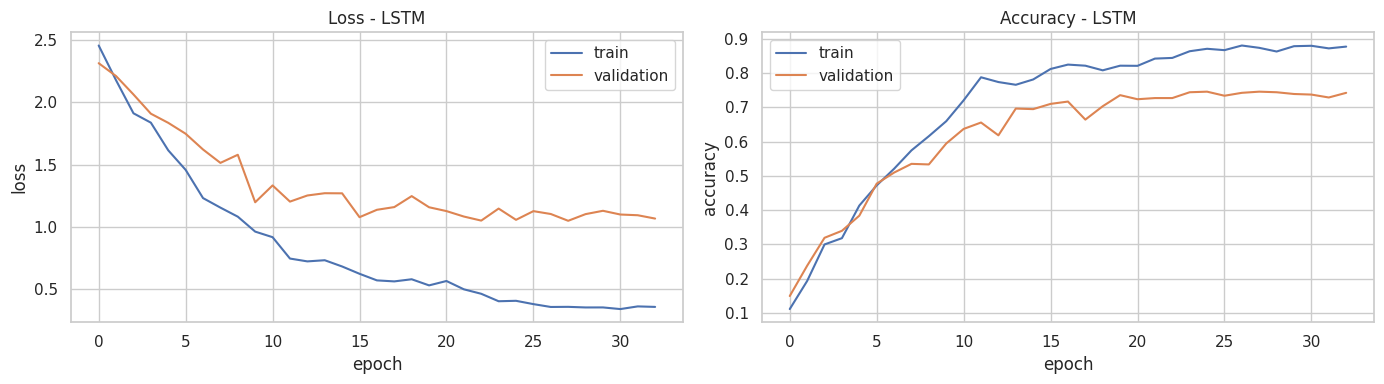

In [54]:
res_lstm = train_and_evaluate('LSTM')
plot_curves(res_lstm['history'], 'LSTM')

### 11.2 GRU

GRU: 206,477 parameters
  epoch   1  train 2.400/0.127   val 2.430/0.114
  epoch   5  train 1.257/0.564   val 1.372/0.582
  epoch  10  train 0.651/0.805   val 1.102/0.728
  epoch  15  train 0.419/0.859   val 0.990/0.757
  epoch  20  train 0.394/0.876   val 0.961/0.769
  epoch  25  train 0.267/0.901   val 0.953/0.789
  epoch  30  train 0.236/0.917   val 1.007/0.805
  epoch  35  train 0.229/0.924   val 0.996/0.815
  epoch  40  train 0.225/0.927   val 1.061/0.810
  epoch  45  train 0.208/0.938   val 1.042/0.818
  epoch  50  train 0.214/0.930   val 1.052/0.815
  best val loss 1.0537 / accuracy 0.8200  (32s)

  GRU — Results
  Accuracy:          0.8420
  F1 (weighted):     0.8407
  F1 (macro):        0.7691
  Precision (w):     0.8461
  Recall (w):        0.8420
  Top-3 Accuracy:    0.9637
  Top-5 Accuracy:    0.9800

              precision    recall  f1-score   support

    Point-1f       0.93      0.98      0.95       265
    Point-2f       0.98      0.93      0.96       264
    Click-1f

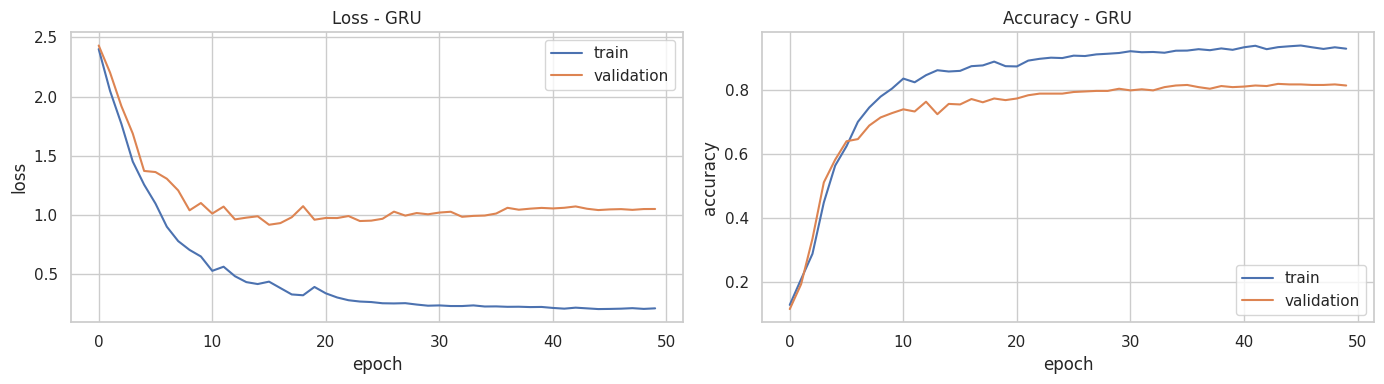

In [55]:
res_gru = train_and_evaluate('GRU')
plot_curves(res_gru['history'], 'GRU')

### 11.3 BiGRU

BiGRU: 510,349 parameters
  epoch   1  train 2.386/0.140   val 2.321/0.136
  epoch   5  train 0.799/0.740   val 1.098/0.718
  epoch  10  train 0.425/0.844   val 0.945/0.723
  epoch  15  train 0.278/0.904   val 0.817/0.788
  epoch  20  train 0.218/0.938   val 0.842/0.815
  epoch  25  train 0.123/0.969   val 0.789/0.830
  epoch  30  train 0.061/0.987   val 0.947/0.822
  early stopping at epoch 32
  best val loss 0.8050 / accuracy 0.8387  (32s)

  BiGRU — Results
  Accuracy:          0.8683
  F1 (weighted):     0.8634
  F1 (macro):        0.8103
  Precision (w):     0.8718
  Recall (w):        0.8683
  Top-3 Accuracy:    0.9718
  Top-5 Accuracy:    0.9837

              precision    recall  f1-score   support

    Point-1f       0.90      0.98      0.94       265
    Point-2f       0.98      0.94      0.96       264
    Click-1f       0.65      0.75      0.70        52
    Click-2f       0.60      0.77      0.67        52
    Throw-up       0.91      0.81      0.86        52
  Throw-down 

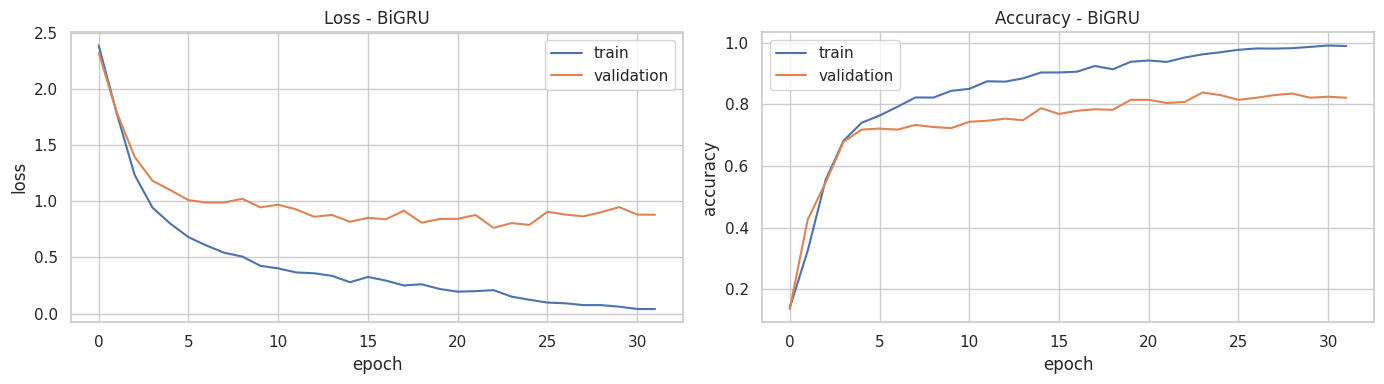

In [56]:
res_bigru = train_and_evaluate('BiGRU')
plot_curves(res_bigru['history'], 'BiGRU')

### 11.4 Tuned BiGRU

Loaded from disk rather than retrained - this is the model from section 9.

In [57]:
# The tuned model from section 9, loaded from disk instead of retrained.
set_seed(42)
final_model = GestureRNN(input_size=INPUT_SIZE,
                         hidden_size=best_config['hidden_size'],
                         num_layers=best_config['num_layers'],
                         dropout=best_config['dropout'],
                         rnn_type=best_config['rnn_type'],
                         bidirectional=best_config['bidirectional'])
final_model.load_state_dict(
    torch.load(f"results/models/best_{BEST_ARCH}.pth", map_location=device))

yt, yp, yprob = predict(final_model, test_loader)
res = full_evaluation(yt, yp, model_name=f"{BEST_ARCH}_final", save_dir=RESULTS_DIR,
                      y_prob=yprob, show_plot=False)

final_model.to(device).eval()
def predict_one(x):
    with torch.no_grad():
        return final_model(x.to(device), len_one)
res['inference_ms'] = measure_inference_time(predict_one, x_one, n_runs=50)['mean_ms']
res['parameters'] = count_parameters(final_model)
res['train_time_s'] = final_time

all_results[f"{BEST_ARCH}_final"] = res
print(f"{BEST_ARCH}_final: test accuracy {res['accuracy']:.4f}  "
      f"weighted F1 {res['f1_weighted']:.4f}")


  BiGRU_final — Results
  Accuracy:          0.8883
  F1 (weighted):     0.8876
  F1 (macro):        0.8438
  Precision (w):     0.8901
  Recall (w):        0.8883
  Top-3 Accuracy:    0.9764
  Top-5 Accuracy:    0.9864

              precision    recall  f1-score   support

    Point-1f       0.94      0.97      0.96       265
    Point-2f       0.98      0.94      0.96       264
    Click-1f       0.71      0.67      0.69        52
    Click-2f       0.72      0.69      0.71        52
    Throw-up       0.90      0.83      0.86        52
  Throw-down       0.95      1.00      0.97        52
  Throw-left       0.95      1.00      0.97        52
 Throw-right       0.72      0.94      0.82        52
  Open-twice       0.91      0.94      0.92        52
 DblClick-1f       0.73      0.73      0.73        52
 DblClick-2f       0.83      0.73      0.78        52
     Zoom-in       0.78      0.83      0.80        52
    Zoom-out       0.88      0.73      0.80        52

    accuracy        

### 11.5 Comparison table

      Model     Approach  Accuracy  F1 (weighted)  F1 (macro)  Inference (ms)  Parameters  Train time (s)
BiGRU_final Landmark seq    0.8883         0.8876      0.8438            3.81     2988941              64
      BiGRU Landmark seq    0.8683         0.8634      0.8103            2.92      510349              32
        GRU Landmark seq    0.8420         0.8407      0.7691            1.88      206477              32
       LSTM Landmark seq    0.8047         0.7987      0.7198            1.84      272269              22


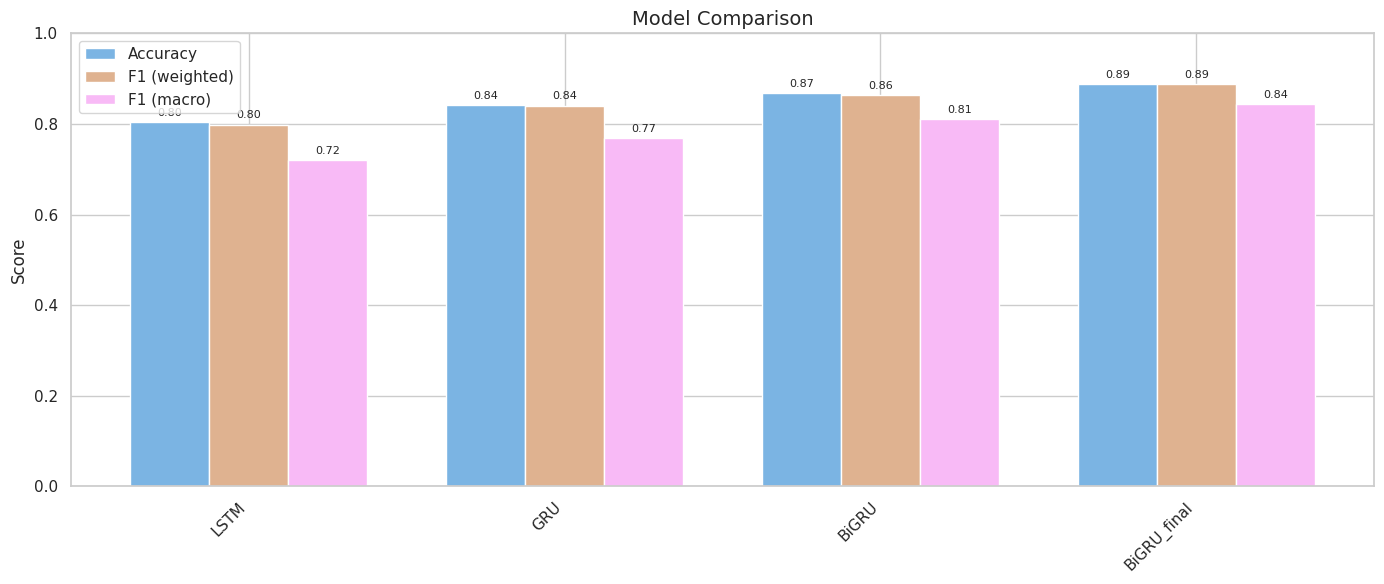


  FINAL MODEL COMPARISON
  Model                       Accuracy     F1 (w)     F1 (m)
  -------------------------------------------------------
  BiGRU_final                   0.8883     0.8876     0.8438
  BiGRU                         0.8683     0.8634     0.8103
  GRU                           0.8420     0.8407     0.7691
  LSTM                          0.8047     0.7987     0.7198



In [62]:
comparison = pd.DataFrame([{
    'Model': r['model'],
    'Approach': 'Landmark seq',
    'Accuracy': round(r['accuracy'], 4),
    'F1 (weighted)': round(r['f1_weighted'], 4),
    'F1 (macro)': round(r['f1_macro'], 4),
    'Inference (ms)': round(r['inference_ms'], 2),
    'Parameters': r['parameters'],
    'Train time (s)': round(r.get('train_time_s')) if r.get('train_time_s') else None,
} for r in all_results.values()]).sort_values('F1 (weighted)', ascending=False)

print(comparison.to_string(index=False))
comparison.to_csv("results/lstm_model_comparison.csv", index=False)

compare_models(list(all_results.values()), save_dir=RESULTS_DIR)

Among the three architectures trained under the common configuration, the ordering is consistent
across all three metrics: BiGRU (0.863 weighted F1) > GRU (0.841) > LSTM (0.799).

Two patterns hold. Bidirectional reading is worth ~0.02 weighted F1 over the
unidirectional GRU, confirming that the end of an isolated clip carries as much information as
its start. And GRU beats LSTM by 4 points *with fewer parameters* (206k against 272k) - with only
2515 training samples, the simpler gating generalises better.

The effect is largest on macro F1 (LSTM 0.720 to BiGRU 0.810), so most of what these choices buy
is on the harder, rarer gestures rather than on the dominant Point classes.

`BiGRU_final` adds a further 2.4 points of weighted F1 over the plain BiGRU row - that gap is the
contribution of the hyperparameter search, at the cost of 5.9x the parameters.

## 12. Save results for the joint comparison

In [ ]:
import os, json

os.makedirs("results", exist_ok=True)
os.makedirs("results/models", exist_ok=True)

best = all_results[f"{BEST_ARCH}_final"]

summary = {
    'model': f"{BEST_ARCH}_final",
    'approach': 'landmark sequence (RNN)',
    'accuracy': float(best['accuracy']),
    'f1_weighted': float(best['f1_weighted']),
    'f1_macro': float(best['f1_macro']),
    'inference_ms': float(best['inference_ms']),
    'parameters': int(best['parameters']),
    'config': best_config,
}

with open("results/BiGRU_final.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "model": "BiGRU_final",
  "approach": "landmark sequence (RNN)",
  "accuracy": 0.888283378746594,
  "f1_weighted": 0.8876182510169393,
  "f1_macro": 0.8437585379798445,
  "inference_ms": 3.8112108200039074,
  "parameters": 2988941,
  "config": {
    "rnn_type": "gru",
    "bidirectional": true,
    "hidden_size": 256,
    "num_layers": 3,
    "dropout": 0.3,
    "lr": 0.0009656520212777109,
    "t_fixed": 120,
    "use_velocity": true
  }
}


### 12.1 Feature scaler

Required to preprocess any new sequence exactly as the training data was preprocessed.

In [60]:
from src.models.landmark_dataset import add_velocity, fit_scaler

prep = [add_velocity(s) for s in tr_seqs] if USE_VELOCITY else tr_seqs
mean, std = fit_scaler(prep)

np.savez("results/models/scaler.npz", mean=mean, std=std,
         t_fixed=T_FIXED, use_velocity=USE_VELOCITY)

print("saved:", sorted(os.listdir("results/models")))

saved: ['BiGRU.pth', 'GRU.pth', 'LSTM.pth', 'best_BiGRU.pth', 'scaler.npz']
